In [1]:
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
    MonodromyLPGate,
    MonodromyLPISA,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from qiskit.circuit.library import CXGate, CZGate, SwapGate, iSwapGate
from qiskit.quantum_info.random import random_unitary

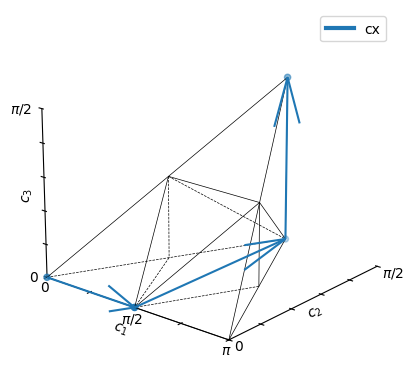

In [4]:
isa_handler = ISAHandler([CXGate()], [1.0], ["cx"])
decomposer = MonodromyLPDecomposer(isa_handler)
target = SwapGate()
result = decomposer._best_decomposition(target)
result.render_path();

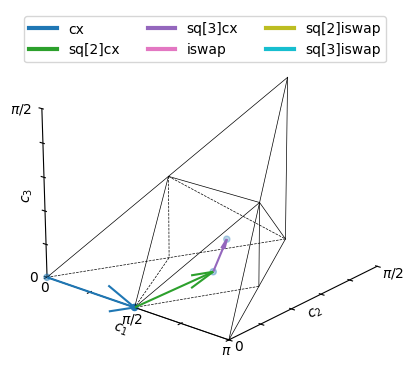

In [5]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        iSwapGate(),
        iSwapGate().power(1 / 2),
        iSwapGate().power(1 / 3),
    ],
    [1.0, 1 / 2, 1 / 3, 2, 1, 2 / 3],
    ["cx", "sq[2]cx", "sq[3]cx", "iswap", "sq[2]iswap", "sq[3]iswap"],
)
decomposer = MonodromyLPDecomposer(isa_handler)
target = random_unitary(4).to_matrix()
result = decomposer._best_decomposition(target)
result.render_path();

In [ ]:
# qlr_inequalities = np.array(generate_qlr_inequalities())


# def _single_L(c_i, g_i, c_ip1):
#     A = np.zeros((72, 9))  # 72 rows per qlr_inequalities()
#     b = np.zeros((72, 1))

#     # NOTE c_i, given coordinate
#     A[:, range(3)] += -1.0 * qlr_inequalities[:, 1:4]  # alphas
#     # NOTE g_i, given basis gate
#     A[:, range(3, 6)] += -1.0 * qlr_inequalities[:, 4:7]  # betas
#     # NOTE c_{i+1}, target coordinate
#     A[:, range(6, 9)] += -1.0 * qlr_inequalities[:, 7:10]  # gammas
#     b[:, 0] = qlr_inequalities[:, 0]

#     A_eq = np.eye(9)
#     # A_eq[range(6, 9), :] = 0
#     b_eq = np.array(list(c_i) + list(g_i) + list(c_ip1))
#     # b_eq = np.array(list(c_i) + list(g_i) + [0, 0, 0])

#     c = np.zeros(9)  # for generic feasibility

#     ret = linprog(
#         *(c, A, b, A_eq, b_eq),
#         bounds=(None, None),
#         method="highs-ds",
#     )
#     return ret


# # verify
# for idx in range(len(mono_result.isa_sequence)):
#     intermediate_ret = _single_L(
#         mono_result.mono_points[idx],
#         mono_result.isa_sequence[idx].definition,
#         mono_result.mono_points[idx + 1],
#     )
#     print(intermediate_ret.success)